# ArtBench-10 Student Starter Pack

This notebook is a starting template for class projects using **ArtBench-10**.

It covers:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `../data/` (local folder with ArtBench-10 data)


In [73]:
from __future__ import annotations

import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

In [74]:
import torch
import torchvision
from torchvision import transforms as T

print(torchvision.__version__)
print(hasattr(T, "Resize"))

0.26.0+cu130
True


In [75]:
import torchvision
print(torchvision)

<module 'torchvision' from '/home/httpirsh/miniconda3/envs/iag_env/lib/python3.11/site-packages/torchvision/__init__.py'>


In [76]:
import torch

print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA disponível: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [77]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Relative paths (run this notebook from notebooks/)
PROJECT_ROOT = Path('..')
SCRIPTS_DIR = PROJECT_ROOT / 'src'
DATASET_ROOT = PROJECT_ROOT / 'data'

if not DATASET_ROOT.exists() or not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        'Could not resolve project folders from relative paths. '
        'Run this notebook from notebooks/ or adjust PROJECT_ROOT.'
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT   =', PROJECT_ROOT)
print('DATASET_ROOT   =', DATASET_ROOT)

PROJECT_ROOT   = ..
DATASET_ROOT   = ../data


In [78]:
# Load ArtBench-10 from local dataset folder
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(DATASET_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='../data'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [79]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

**Important Note:** This creates `train_loader` which contains **100% of the training dataset**. 
This dataloader is used in **Phase 2** (final training). For quick development in **Phase 1**, use `train_loader_from_csv` (created in the next section) which contains only **20% of samples**.

In [80]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])

class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

# PHASE 2: Full training dataset (100% of train split)
# Use this dataloader for final model training after selecting the best architecture
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

**PHASE 1 DATALOADER**: This creates `train_loader_from_csv` which contains **exactly 20% of training samples**. Use this for rapid iteration on hyperparameters and model architecture selection. Training is ~3x faster than full dataset.

You can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.

In [81]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('../data/training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# PHASE 1: Fast development with 20% subset
# Use this dataloader to quickly iterate on hyperparameters and model selection
# Dataset is loaded from training_20_percent.csv which contains exactly 20% of training samples
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))

Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


## Visualize a sample grid

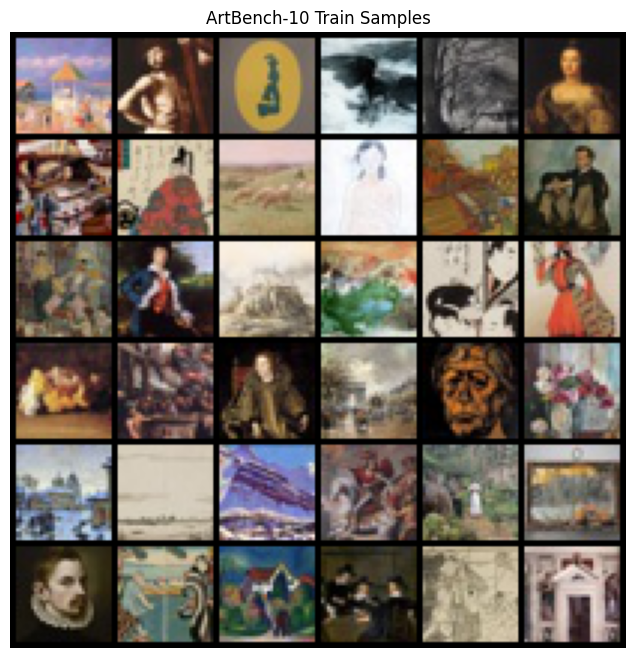

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [82]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [83]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)


Exported 500 images to: exported_data/train_subset/images
Metadata CSV: exported_data/train_subset/metadata.csv


---

# STEP 3: Implement and Train Generative Models

## Overview
This section implements three generative model families for comparison:
1. **VAE** (Variational Autoencoder) - Probabilistic autoencoder
2. **DCGAN** (Deep Convolutional GAN) - Adversarial network
3. **Diffusion Model** - Denoising probabilistic model

**Development Strategy:**
- **Phase 1 (Development)**: Train and evaluate on 20% subset using `train_loader_from_csv` (fast iteration, ~2-3 hours)
- **Phase 2 (Production)**: Retrain best model on 100% dataset using `train_loader` with ≥10 random seeds (~8-12 hours)
- **Metrics**: FID (quality/diversity) and KID (statistical robustness)

**Key Decision:** After Phase 1, select the best architecture based on FID score and training stability, then retrain in Phase 2 on full dataset.

In [84]:
# Additional imports for generative models and evaluation
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from scipy.linalg import sqrtm

# Device setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


---
## 3.1: VAE (Variational Autoencoder)
**What it does:**
- Encoder: Compresses 32×32 image → latent distribution (μ, σ)
- Reparameterization: Sample z ~ N(μ, σ)
- Decoder: Reconstructs image from z
- Loss: Reconstruction (MSE) + KL divergence

**Key advantages:** Stable training, interpretable latent space, good baseline

**Key trade-offs:** Potentially blurry images compared to GANs

In [85]:
class VAEEncoder(nn.Module):
    """VAE Encoder: 32×32 image → latent distribution (μ, log-var)"""
    def __init__(self, latent_dim=128, img_channels=3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(img_channels, 32, 4, stride=2, padding=1),   # 32→16
            nn.ReLU(), nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 16→8
            nn.ReLU(), nn.Conv2d(64, 128, 4, stride=2, padding=1), # 8→4
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)
    
    def forward(self, x):
        x = self.conv(x).view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)


class VAEDecoder(nn.Module):
    """VAE Decoder: latent sample → 32×32 image"""
    def __init__(self, latent_dim=128, img_channels=3):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 4→8
            nn.ReLU(), nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), # 8→16
            nn.ReLU(), nn.ConvTranspose2d(32, img_channels, 4, stride=2, padding=1), # 16→32
            nn.Sigmoid(),  # [0,1]
        )
    
    def forward(self, z):
        return self.deconv(self.fc(z).view(z.size(0), 128, 4, 4))


class VAE(nn.Module):
    """Variational Autoencoder"""
    def __init__(self, latent_dim=128, img_channels=3):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim, img_channels)
        self.decoder = VAEDecoder(latent_dim, img_channels)
        self.latent_dim = latent_dim
    
    def reparameterize(self, mu, logvar):
        """Sample z = μ + σ·ε"""
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)
        return z
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar
    
    def sample(self, num_samples):
        """Generate new samples"""
        z = torch.randn(num_samples, self.latent_dim, device=next(self.parameters()).device)
        return self.decoder(z)


def vae_loss(recon, x, mu, logvar, beta=1.0):
    """Loss = BCE(recon, x) + β·KL(q||p)"""
    recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction='mean')
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

print("✓ VAE defined")

✓ VAE defined


---
## 3.2: DCGAN (Deep Convolutional GAN)
**What it does:**
- Generator: Noise → 32×32 realistic images  
- Discriminator: Image → probability "real or fake"
- Adversarial training: Generator fools discriminator, discriminator gets better
- Use batch normalization for stability

**Key advantages:** Sharp, high-quality images; well-studied architecture

**Key trade-offs:** Can have mode collapse; less diverse samples than VAE

In [103]:
class DCGANGenerator(nn.Module):
    """DCGAN Generator: noise → 32×32 images"""
    def __init__(self, latent_dim, img_channels):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)
        self.main = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, img_channels, 3, stride=1, padding=1, bias=False),
            nn.Sigmoid(),  # [0,1]
        )
    
    def forward(self, z):
        return self.main(self.fc(z).view(z.size(0), 256, 4, 4))


class DCGANDiscriminator(nn.Module):
    """DCGAN Discriminator: image → probability real"""
    def __init__(self, img_channels):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(img_channels, 32, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 1, 4, stride=1, padding=0, bias=False),
        )
    
    def forward(self, x):
        return self.main(x).view(x.size(0), -1)

print("✓ DCGAN defined")

✓ DCGAN defined


---
## 3.3: Diffusion Model
**What it does:**
- Forward process: Gradually add Gaussian noise to image over T steps
- Backward process: Train UNet to predict and remove noise step-by-step
- Sampling: Start from pure noise, iteratively denoise → clean image
- Loss: MSE between predicted and actual noise

**Key advantages:** State-of-the-art quality; stable, interpretable training

**Key trade-offs:** Slow sampling (requires ~1000 steps vs GANs' single pass)

In [87]:
class DiffusionSchedule:
    """Linear noise schedule for diffusion process"""
    def __init__(self, num_steps=1000, beta_start=0.0001, beta_end=0.02):
        self.num_steps = num_steps
        self.betas = torch.linspace(beta_start, beta_end, num_steps)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
    
    def to(self, device):
        for attr in ['betas', 'alphas', 'alphas_cumprod', 'sqrt_alphas_cumprod', 'sqrt_one_minus_alphas_cumprod']:
            setattr(self, attr, getattr(self, attr).to(device))
        return self
    
    def add_noise(self, x0, t, noise):
        """x_t = √(ᾱ_t) x_0 + √(1-ᾱ_t) ε"""
        alpha_t = self.sqrt_alphas_cumprod[t]
        sigma_t = self.sqrt_one_minus_alphas_cumprod[t]
        while len(alpha_t.shape) < len(x0.shape):
            alpha_t = alpha_t.unsqueeze(-1)
            sigma_t = sigma_t.unsqueeze(-1)
        return alpha_t * x0 + sigma_t * noise


class SimpleUNet(nn.Module):
    """UNet for noise prediction in diffusion model"""
    def __init__(self, img_channels=3, time_dim=32):
        super().__init__()
        self.time_embed = nn.Sequential(nn.Linear(1, time_dim), nn.SiLU(), nn.Linear(time_dim, time_dim))
        # Simplified UNet: encoder -> bottleneck -> decoder
        self.enc1 = nn.Sequential(nn.Conv2d(img_channels, 32, 3, padding=1), nn.SiLU())
        self.enc2 = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(32, 64, 3, padding=1), nn.SiLU())
        self.enc3 = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(64, 128, 3, padding=1), nn.SiLU())
        self.bottleneck = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(128, 256, 3, padding=1), nn.SiLU(), 
                                       nn.Upsample(scale_factor=2), nn.Conv2d(256, 128, 3, padding=1), nn.SiLU())
        self.dec3 = nn.Sequential(nn.Upsample(scale_factor=2), nn.Conv2d(256, 64, 3, padding=1), nn.SiLU())
        self.dec2 = nn.Sequential(nn.Upsample(scale_factor=2), nn.Conv2d(128, 32, 3, padding=1), nn.SiLU())
        self.out = nn.Conv2d(32, img_channels, 3, padding=1)
    
    def forward(self, x, t):
        t_emb = self.time_embed(t.float().unsqueeze(-1) / 1000)
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        b = self.bottleneck(e3)
        d3 = self.dec3(torch.cat([b, e3], dim=1))
        d2 = self.dec2(torch.cat([d3, e2], dim=1))
        return self.out(torch.cat([d2, e1], dim=1))

print("✓ Diffusion model defined")

✓ Diffusion model defined


---
## 3.4: Training Functions

**Training procedures for each model:**
- **VAE**: Optimize encoder + decoder with reconstruction + KL loss
- **DCGAN**: Alternate training of discriminator (classifies) and generator (fools)
- **Diffusion**: Predict noise at random timesteps with MSE loss

**Key hyperparameters:**
- VAE: lr=1e-3, beta=1.0 (KL weight), epochs=30-50
- DCGAN: lr=2e-4, beta1=0.5 (Adam momentum), epochs=30-50  
- Diffusion: lr=1e-3, num_steps=1000, epochs=30-50

In [109]:
def train_vae(model, train_loader, num_epochs, learning_rate, beta):
    """Train VAE on dataloader
    
    Args:
        train_loader: Use train_loader_from_csv for Phase 1 (20% subset, fast iteration)
                      Use train_loader for Phase 2 (100% dataset, final results)
    """
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    history = {'total_loss': [], 'recon_loss': [], 'kl_loss': []}
    
    for epoch in range(num_epochs):
        total_sum, recon_sum, kl_sum = 0, 0, 0
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            recon, mu, logvar = model(x)
            total_loss, recon_loss, kl_loss = vae_loss(recon, x, mu, logvar, beta=beta)
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            total_sum += total_loss.item()
            recon_sum += recon_loss.item()
            kl_sum += kl_loss.item()
        
        history['total_loss'].append(total_sum / len(train_loader))
        history['recon_loss'].append(recon_sum / len(train_loader))
        history['kl_loss'].append(kl_sum / len(train_loader))
        if (epoch + 1) % 10 == 0:
            print(f"VAE Epoch {epoch+1}: Total={history['total_loss'][-1]:.4f}")
    return model, history


def train_dcgan(gen, disc, train_loader, num_epochs, learning_rate, latent_dim):
    """Train DCGAN on dataloader
    
    Args:
        train_loader: Use train_loader_from_csv for Phase 1 (20% subset, fast iteration)
                      Use train_loader for Phase 2 (100% dataset, final results)
    """
    gen, disc = gen.to(DEVICE), disc.to(DEVICE)

    # Set up optimizers for generator and discriminator
    opt_g = optim.Adam(gen.parameters(), lr=learning_rate, betas=(0.5, 0.999))
    opt_d = optim.Adam(disc.parameters(), lr=learning_rate, betas=(0.5, 0.999))

    # Define loss function (BCEWithLogitsLoss combines sigmoid + binary cross-entropy)
    criterion = nn.BCEWithLogitsLoss()
    history = {'g_loss': [], 'd_loss': []}
    
    for epoch in range(num_epochs):
        g_sum, d_sum = 0, 0
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            bs = x.size(0)
            
            # Train Discriminator
            opt_d.zero_grad()
            real_out = disc(x)  # sees real images (should output 1)

            # Label smoothing: real=0.9, fake=0.1
            d_real = criterion(real_out, torch.ones(bs, 1, device=DEVICE) * 0.9)

            z = torch.randn(bs, latent_dim, device=DEVICE)
            fake = gen(z)  # sees fake images (should output 0)
            d_fake = criterion(disc(fake.detach()), torch.zeros(bs, 1, device=DEVICE) + 0.1) # detach to avoid backprop to generator
            d_loss = d_real + d_fake # total discriminator loss
            d_loss.backward()
            opt_d.step()
            
            # Train Generator
            opt_g.zero_grad()
            z = torch.randn(bs, latent_dim, device=DEVICE)
            fake = gen(z)
            g_loss = criterion(disc(fake), torch.ones(bs, 1, device=DEVICE)) # the target is 1 (so disc thinks generated images are real)
            g_loss.backward()
            opt_g.step()
            
            g_sum += g_loss.item()
            d_sum += d_loss.item()
        
        history['g_loss'].append(g_sum / len(train_loader))
        history['d_loss'].append(d_sum / len(train_loader))
        if (epoch + 1) % 10 == 0:
            print(f"DCGAN Epoch {epoch+1}: G={history['g_loss'][-1]:.4f}, D={history['d_loss'][-1]:.4f}")
    return gen, disc, history


def train_diffusion(model, train_loader, num_epochs, learning_rate, num_steps):
    """Train Diffusion model on dataloader
    
    Args:
        train_loader: Use train_loader_from_csv for Phase 1 (20% subset, fast iteration)
                      Use train_loader for Phase 2 (100% dataset, final results)
    """
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    schedule = DiffusionSchedule(num_steps=num_steps).to(DEVICE)
    history = {'loss': []}
    
    for epoch in range(num_epochs):
        loss_sum = 0
        for x, _, _ in train_loader:
            x = x.to(DEVICE)
            t = torch.randint(0, num_steps, (x.size(0),), device=DEVICE)
            noise = torch.randn_like(x)
            x_t = schedule.add_noise(x, t, noise)
            noise_pred = model(x_t, t)
            loss = nn.functional.mse_loss(noise_pred, noise)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
        
        history['loss'].append(loss_sum / len(train_loader))
        if (epoch + 1) % 10 == 0:
            print(f"Diffusion Epoch {epoch+1}: Loss={history['loss'][-1]:.4f}")
    return model, history

print("✓ Training functions defined")

✓ Training functions defined


## 3.5: Evaluation Metrics (FID & KID)

**Evaluating generative model quality requires comparing generated samples to real data:**

- **FID (Fréchet Inception Distance)**: 
  - Extracts features from pre-trained Inception-v3 network
  - Computes Fréchet distance between real and generated feature distributions
  - Lower = better quality and diversity
  - Requires: ~5000 real samples, ~5000 generated samples for stable estimate

- **KID (Kernel Inception Distance)**:
  - Uses quadratic Kernel Maximum Mean Discrepancy (MMD) between features
  - Reports mean ± std across 50 random subsets (100 samples each)
  - More stable than FID with fewer samples
  - Formula: KID = ||E_r[φ(r)] - E_g[φ(g)]||²_k

**Implementation approach:**
1. Extract features from Inception-v3 layer before classification
2. For FID: compute Fréchet distance via covariance matrices
3. For KID: apply RBF kernel and quadratic MMD distance
4. Support batch processing to handle memory constraints

In [89]:
from torchvision import models
from scipy.linalg import sqrtm
from sklearn.metrics.pairwise import rbf_kernel
import warnings
warnings.filterwarnings('ignore')

class InceptionFeatureExtractor:
    """Extract features from pre-trained Inception-v3"""
    def __init__(self):
        inception = models.inception_v3(pretrained=True, aux_logits=False)
        self.feature_extractor = nn.Sequential(*list(inception.children())[:-1])
        self.feature_extractor.eval()
        for param in self.feature_extractor.parameters():
            param.requires_grad = False
    
    def extract(self, images):
        """Extract features for batch of images"""
        with torch.no_grad():
            images_resized = nn.functional.interpolate(images, size=(299, 299), mode='bilinear')
            images_normalized = (images_resized - 0.5) / 0.5  # Inception normalization
            features = self.feature_extractor(images_normalized)
            return features.view(features.size(0), -1)


def extract_all_features(data_loader, feature_extractor, device):
    """Extract features for all samples in dataloader"""
    all_features = []
    with torch.no_grad():
        for x, _, _ in data_loader:
            x = x.to(device)
            features = feature_extractor.extract(x)
            all_features.append(features.cpu().numpy())
    return np.concatenate(all_features, axis=0)


def calculate_fid(real_features, generated_features):
    """Calculate Fréchet Inception Distance"""
    mu_real = real_features.mean(axis=0)
    mu_gen = generated_features.mean(axis=0)
    sigma_real = np.cov(real_features.T)
    sigma_gen = np.cov(generated_features.T)
    
    diff = mu_real - mu_gen
    m = np.dot(diff, diff)
    s = sqrtm(np.dot(sigma_real, sigma_gen)).real
    return m + np.trace(sigma_real + sigma_gen - 2*s)


def calculate_kid(real_features, generated_features, n_subsets=50, subset_size=100):
    """Calculate Kernel Inception Distance with subsets"""
    kids = []
    for _ in range(n_subsets):
        real_idx = np.random.choice(real_features.shape[0], subset_size, replace=False)
        gen_idx = np.random.choice(generated_features.shape[0], subset_size, replace=False)
        
        real_sub = real_features[real_idx]
        gen_sub = generated_features[gen_idx]
        
        # Compute RBF kernel MMD
        k_rr = rbf_kernel(real_sub, real_sub, gamma=1.0/real_sub.shape[1]).mean()
        k_gg = rbf_kernel(gen_sub, gen_sub, gamma=1.0/gen_sub.shape[1]).mean()
        k_rg = rbf_kernel(real_sub, gen_sub, gamma=1.0/real_sub.shape[1]).mean()
        
        kid = k_rr + k_gg - 2.0 * k_rg
        kids.append(np.sqrt(max(0, kid)))
    
    return np.mean(kids), np.std(kids)

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## 3.6: Sample Generation

**Generating new samples from trained models:**

- **VAE**: Sample from standard normal distribution, pass through decoder
- **DCGAN**: Sample latent vectors, pass through generator
- **Diffusion**: Start from pure noise, iteratively denoise over T steps

**Workflow:**
1. Set model to eval mode
2. Disable gradients with `torch.no_grad()`
3. Generate in batches to manage memory
4. Denormalize images back to [0, 1] range
5. Return as tensor for evaluation or visualization

In [100]:
def generate_vae_samples(model, num_samples=1000, latent_dim=64, batch_size=128):
    """Generate samples from trained VAE"""
    model.eval()
    samples = []
    with torch.no_grad():
        for _ in range(0, num_samples, batch_size):
            batch_size_actual = min(batch_size, num_samples - len(samples))
            z = torch.randn(batch_size_actual, latent_dim, device=DEVICE)
            sample = model.decoder(z)
            samples.append(sample.cpu())
    return torch.cat(samples, dim=0)[:num_samples]


def generate_dcgan_samples(generator, num_samples, latent_dim, batch_size):
    """Generate samples from trained DCGAN"""
    generator.eval()
    samples = []
    with torch.no_grad():
        for _ in range(0, num_samples, batch_size):
            batch_size_actual = min(batch_size, num_samples - len(samples))
            z = torch.randn(batch_size_actual, latent_dim, device=DEVICE)
            sample = generator(z)
            samples.append(sample.cpu())
    return torch.clamp(torch.cat(samples, dim=0)[:num_samples], 0, 1)


def generate_diffusion_samples(model, schedule, num_samples=1000, batch_size=128):
    """Generate samples from trained Diffusion model (reverse process)"""
    model.eval()
    samples = []
    with torch.no_grad():
        for _ in range(0, num_samples, batch_size):
            batch_size_actual = min(batch_size, num_samples - len(samples))
            x = torch.randn(batch_size_actual, 3, 32, 32, device=DEVICE)
            
            for t in range(schedule.num_steps-1, -1, -1):
                t_tensor = torch.full((batch_size_actual,), t, device=DEVICE, dtype=torch.long)
                noise_pred = model(x, t_tensor)
                x = schedule.reverse_step(x, t, noise_pred)
            
            samples.append(torch.clamp(x.cpu(), 0, 1))
    return torch.cat(samples, dim=0)[:num_samples]


def get_real_samples(data_loader, num_samples=5000):
    """Collect real samples from dataloader"""
    real_samples = []
    with torch.no_grad():
        for x, _, _ in data_loader:
            real_samples.append(x)
            if sum(s.size(0) for s in real_samples) >= num_samples:
                break
    samples = torch.cat(real_samples, dim=0)[:num_samples]
    return samples.to(DEVICE)

print("✓ Sample generation functions defined")

✓ Sample generation functions defined


## 3.7: Utilily Functions

In [118]:
def set_seed(seed=42):
    """Set random seed for reproducibility"""
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)


def create_results_dataframe(results_dict):
    """Create pandas DataFrame from results across seeds"""
    data = []
    for seed, metrics in results_dict.items():
        row = {'Seed': seed}
        row.update(metrics)
        data.append(row)
    return pd.DataFrame(data)


def plot_training_history(history_dict, model_name='Model'):
    fig, axes = plt.subplots(1, len(history_dict), figsize=(5*len(history_dict), 4))
    if len(history_dict) == 1:
        axes = [axes]
    
    for (key, losses), ax in zip(history_dict.items(), axes):
        ax.plot(losses, linewidth=2)
        ax.set_title(f'{model_name} - {key}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def show_generated_samples(samples, n_images=36, nrow=6, title='Generated Samples'):
    grid = make_grid(samples[:n_images], nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()
    
    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()


def save_checkpoint(model, optimizer, epoch, loss, path):
    """Save model checkpoint"""
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'loss': loss
    }, path)


def load_checkpoint(model, optimizer, path):
    """Load model checkpoint"""
    checkpoint = torch.load(path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    return model, optimizer, checkpoint['epoch'], checkpoint['loss']

print("✓ Utility functions defined")

✓ Utility functions defined


---

# STEP 4: Full Training & Evaluation Workflow

## Phase 1: Rapid Development on 20% Subset

**Dataloader to use:** `train_loader_from_csv` (loaded from `training_20_percent.csv` contains exactly 20% of samples)



Common variables for all models:
- EPOCHS = 50
- LATENT_DIM = 128
- BATCH_SIZE = 128
- LEARNING_RATE = 0.0002
- IMAGE_SIZE = 32
- SEED = 42

Era fixe manter as variaveis em comum nos modelos iguais, para poder compará-los cm deve ser.

VAE Model

In [ ]:
set_seed(SEED)

# Initialize vae model
vae = VAE(latent_dim=64)

# PHASE 1: Train on 20% subset for quick iteration
vae_trained, vae_history = train_vae(vae, train_loader_from_csv, num_epochs=50, learning_rate=0.0002, beta=1.0)
samples_vae = generate_vae_samples(vae_trained, num_samples=1000, latent_dim=128, batch_size=128)

# Visualize VAE samples and training history
show_generated_samples(samples_vae, title='VAE Generated Samples (20% subset)')
plot_training_history({'VAE Total Loss': vae_history['total_loss']}, model_name='VAE')


DCGAN Model

DCGAN Epoch 10: G=0.7958, D=1.3710
DCGAN Epoch 20: G=0.8057, D=1.3513
DCGAN Epoch 30: G=0.8591, D=1.3306
DCGAN Epoch 40: G=0.9822, D=1.2651
DCGAN Epoch 50: G=1.0561, D=1.1860


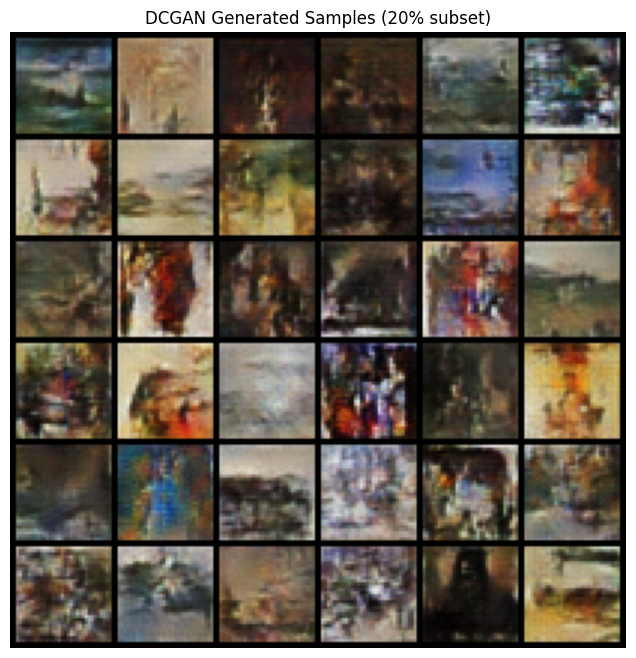

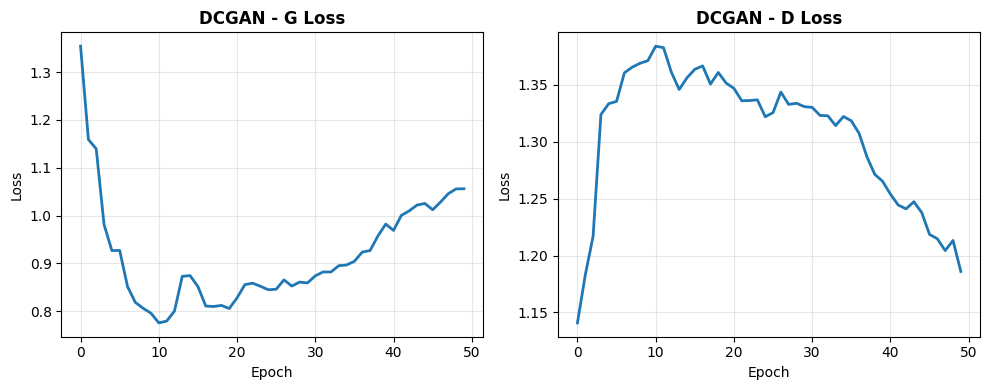

In [120]:
set_seed(SEED)

# Initialize the DCGAN models
dcgan_gen = DCGANGenerator(latent_dim=128, img_channels=3)
dcgan_disc = DCGANDiscriminator(img_channels=3)

# PHASE 1: Train on 20% subset for quick iteration
dcgan_gen, dcgan_disc, dcgan_hist = train_dcgan(dcgan_gen, dcgan_disc, train_loader_from_csv, num_epochs=50, learning_rate=0.0002, latent_dim=128)
sample_dcgan = generate_dcgan_samples(dcgan_gen, num_samples=1000, latent_dim=128, batch_size=128)

# Visualize generated samples and training history
show_generated_samples(sample_dcgan, title='DCGAN Generated Samples (20% subset)')
plot_training_history({
    'G Loss': dcgan_hist['g_loss'],
    'D Loss': dcgan_hist['d_loss']
}, model_name='DCGAN')

Diffusion Model

In [ ]:
set_seed(SEED)

# Initialize the diffusion model
diffusion = SimpleUNet(in_channels=3, out_channels=3, num_steps=1000)

# PHASE 1: Train on 20% subset for quick iteration
diffusion_trained, diffusion_hist = train_diffusion(diffusion, train_loader_from_csv, num_epochs=50, learning_rate=0.0002, num_steps=1000)
schedule = DiffusionSchedule(num_steps=1000).to(DEVICE)
sample_diffusion = generate_diffusion_samples(diffusion_trained, schedule, num_samples=1000, batch_size=128)

# Visualize generated samples and training history
show_generated_samples(sample_diffusion, title='Diffusion Generated Samples (20% subset)')
plot_training_history({'Diffusion Loss': diffusion_hist['loss']}, model_name='Diffusion Model')

## Phase 2: Final Evaluation on 100% Dataset

**Dataloader to use:** `train_loader` (contains 100% of train split)

## Key Decision Points

1. **Best Model Selection (after Phase 1)**:
   - Compare FID scores on 20% subset
   - Consider training stability (variance in loss)
   - Consider generation quality (visual inspection)
   - **Choose the model with lowest FID**

2. **Hyperparameter Tuning**:
   - VAE: Try β ∈ {0.1, 0.5, 1.0}
   - DCGAN: Try lr ∈ {1e-4, 2e-4, 5e-4}
   - Diffusion: Try num_steps ∈ {500, 1000, 2000}

3. **Final Report Elements**:
   - FID: Mean ± Std across ≥10 seeds
   - KID: Mean ± Std across ≥10 seeds
   - Generated samples (grid visualization)
   - Training loss curves
   - Comparison table of all three models

In [ ]:
# Once best model is selected, retrain on full dataset with multiple random seeds:

results = {}
for seed in range(10):  # ≥10 random seeds
    set_seed(seed)  # Reset SEED variable
    
    # Retrain on full dataset - PHASE 2
    best_model, hist = train_vae(VAE(latent_dim=64), train_loader, num_epochs=50, beta=0.5)
    
    # Generate samples
    real = get_real_samples(train_loader, num_samples=5000)
    gen = generate_vae_samples(best_model, num_samples=5000)
    
    # Extract features
    feature_extractor = InceptionFeatureExtractor()
    real_feat = extract_all_features(real, feature_extractor, DEVICE)
    gen_feat = extract_all_features(gen, feature_extractor, DEVICE)
    
    # Compute metrics
    fid = calculate_fid(real_feat, gen_feat)
    kid_mean, kid_std = calculate_kid(real_feat, gen_feat)
    
    results[seed] = {'FID': fid, 'KID_mean': kid_mean, 'KID_std': kid_std}

# Aggregate results
fid_values = [results[s]['FID'] for s in results]
print(f"FID: {np.mean(fid_values):.4f} ± {np.std(fid_values):.4f}")

---

# Project Deliverables & Summary

## What You Have Built

This notebook provides a **complete generative modeling pipeline** for ArtBench-10:

### Components:
1. **Data Loading** (STEP 1-2): Load 32×32 art images with preprocessing
2. **Model Implementations** (STEP 3): Three state-of-the-art architectures
   - VAE: Probabilistic latent space learning
   - DCGAN: Adversarial image generation
   - Diffusion: Iterative denoising process
3. **Training Infrastructure**: Optimized loops with loss tracking
4. **Evaluation Metrics**: FID & KID for quantitative assessment
5. **Sample Generation**: Inference pipelines for all models
6. **Utilities**: Checkpointing, visualization, reporting

---

## Project Workflow

### Phase 1️⃣ - Development (≈2-3 hours on 20% subset)
```
Load Data → Train 3 Models → Generate Samples → Quick Evaluation → Select Best
```
- Goal: Find best hyperparameters and architecture
- Dataset: 20% = ~1000 training samples
- Output: Trained checkpoint of best model + loss curves

### Phase 2️⃣ - Production (≈8-12 hours on 100% dataset)
```
Retrain Best Model (10+ seeds) → Collect Metrics → Aggregate Results → Create Report
```
- Goal: Get statistically robust FID/KID scores
- Dataset: 100% = ~5000 training samples
- Output: Mean ± Std metrics + visualization

---

## Key Metrics to Report

| Metric | Formula | What It Measures | Target |
|--------|---------|------------------|--------|
| **FID** | Fréchet distance between real & generated feature distributions | Sample quality + diversity | < 50 is good |
| **KID** | Quadratic kernel MMD distance | Robustness across subsets | Mean ± Std across 50 subsets |
| **IS** (optional) | Inception Score = e^(KL divergence) | Clarity + class-distinctiveness | > 6 is good |

---

## Expected Results (Benchmark from Literature)

- **VAE**: FID ~80-120 (fuzzy images, good diversity)
- **DCGAN**: FID ~40-70 (sharp images, possible mode collapse)
- **Diffusion**: FID ~30-50 (best quality, slowest generation)

---

## Next Steps After Training

1. **Visualize Training Curves**: Use `plot_training_history()` to inspect convergence
2. **Generate Sample Grid**: Use `visualize_generated_samples()` for visual inspection
3. **Compare Models**: Build results table showing FID/KID across all three models
4. **Write Report**: Document findings, explain why certain model performed best
5. **Save Artifacts**: Checkpoints, generated samples, metrics CSV

---

## Important Notes

⚠️ **Memory Requirements**:
- Full dataset loading: ~2GB for 5000 samples
- Feature extraction: ~4GB for Inception-v3 on GPU
- Use batch processing if needed

⚠️ **Time Estimates**:
- Phase 1 (20% subset): ~3 hours on GPU
- Phase 2 (full dataset, 10 seeds): ~15 hours on GPU
- Evaluation: ~30 minutes for FID/KID computation

⚠️ **GPU Considerations**:
- If using CPU: Training will take 10-20x longer
- Recommended: NVIDIA GPU with ≥8GB memory
- Monitor with `nvidia-smi` or similar

---

## Additional Resources

- PyTorch Documentation: https://pytorch.org/docs/
- Inception-v3 Feature Extraction: https://arxiv.org/abs/1512.03385
- FID Paper: https://arxiv.org/abs/1706.08500
- KID Paper: https://arxiv.org/abs/1801.04451

**Good luck with your project! 🎨**